In [32]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.pipeline import Pipeline

In [6]:
data = load_breast_cancer()

In [8]:
df = pd.DataFrame(data.get('data'), columns=data.get('feature_names'))
df['Target'] = data.get('target')

In [9]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [12]:
X = df[[col for col in df.columns if col != 'Target']].copy()
y = df['Target'].copy()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'X_train shape = {X_train.shape}')
print(f'X_test shape = {X_test.shape}')
print(f'y_train shape = {y_train.shape}')
print(f'y_test shape = {y_test.shape}')

X_train shape = (426, 30)
X_test shape = (143, 30)
y_train shape = (426,)
y_test shape = (143,)


In [17]:
lr = LogisticRegression(max_iter=10000)

In [18]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [26]:
print(f'Accuracy: {lr.score(X_test, y_test)}')
print(f'ROC AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])}')
print(f'Classification Report:\n{classification_report(y_test, lr.predict(X_test))}')

Accuracy: 0.965034965034965
ROC AUC: 0.9977111943404078
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



In [36]:
def print_score(model, X_, y_):
    print(f'Accuracy: {model.score(X_, y_)}')
    print(f'ROC AUC: {roc_auc_score(y_, model.predict_proba(X_)[:, 1])}')
    print(f'Classification Report:\n{classification_report(y_, model.predict(X_))}')

In [33]:
pipe = Pipeline([
    ('StandardScaler', StandardScaler()),
    ('LR', LogisticRegression())
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('StandardScaler', StandardScaler()),
                ('LR', LogisticRegression())])

In [34]:
pipe.score(X_train,y_train)

0.9859154929577465

In [35]:
pipe.score(X_test, y_test)

0.9790209790209791

In [37]:
print_score(pipe, X_train, y_train)

Accuracy: 0.9859154929577465
ROC AUC: 0.9972369166824107
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       158
           1       0.99      0.99      0.99       268

    accuracy                           0.99       426
   macro avg       0.99      0.98      0.98       426
weighted avg       0.99      0.99      0.99       426



In [38]:
print_score(pipe, X_test, y_test)

Accuracy: 0.9790209790209791
ROC AUC: 0.9977111943404079
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [50]:
rfe = RFECV(lr, min_features_to_select=5, cv=5, scoring='roc_auc')

In [51]:
selector = rfe.fit_transform(X_train, y=y_train)

In [55]:
rfe.n_features_

np.int64(23)

In [57]:
len(rfe.get_feature_names_out())

23

In [58]:
pipe.fit(X_train[rfe.get_feature_names_out()], y_train)

Pipeline(steps=[('StandardScaler', StandardScaler()),
                ('LR', LogisticRegression())])

In [59]:
print_score(pipe, X_train[rfe.get_feature_names_out()], y_train)

Accuracy: 0.9882629107981221
ROC AUC: 0.9967173625543171
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       158
           1       0.99      1.00      0.99       268

    accuracy                           0.99       426
   macro avg       0.99      0.99      0.99       426
weighted avg       0.99      0.99      0.99       426



In [60]:
print_score(pipe, X_test[rfe.get_feature_names_out()], y_test)

Accuracy: 0.993006993006993
ROC AUC: 0.9970869746150646
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.99      1.00      0.99        89

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



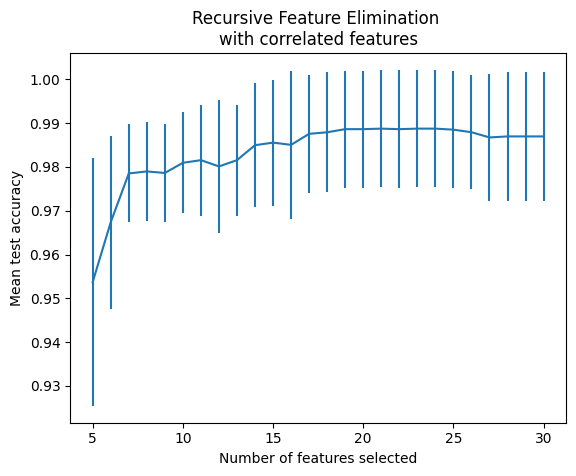

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

cv_results = pd.DataFrame(rfe.cv_results_)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()